# Institutional Holdings Knowledge Graph from SEC 13F Filings

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t`

> **Neo4j required**: This notebook queries a Neo4j graph database.
> Start Neo4j first, then run the notebook:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t python 23_knowledge_graphs/05_institutional_holdings_kg.py
> ```


This notebook demonstrates building a Knowledge Graph from structured SEC 13F
filings, where multi-hop ownership queries are far more cumbersome with flat
tabular analysis (they require repeated self-joins). 13F filings disclose
quarterly equity holdings for institutional managers with over $100M AUM,
creating a natural bipartite graph connecting institutions to stocks.

**Learning Objectives**:
- Design a property graph schema for institutional ownership data
- Build an in-memory graph and translate ownership questions into Cypher queries
- Compute co-ownership similarity (Jaccard) to detect crowded positions
- Load the holdings graph into Neo4j for persistent querying

**Book Reference**: Chapter 23, Section 23.4 (From Graphs to Machine Learning Features)

**Prerequisites**: Familiarity with graph data models (Section 23.2).
A live Neo4j instance is required for the graph loading step.

In [1]:
"""Build an institutional-ownership graph from structured SEC 13F data."""

from __future__ import annotations

import hashlib
import json
import logging
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from data import load_institutional_holdings_13f
from utils.style import COLORS, FIGSIZE, add_message_title

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [2]:
# Production defaults. Papermill overrides them for testing.
# The chapter demo uses the 10 largest institutions x 50 most-held stocks; this
# keeps the in-memory graph small enough to print and reason about by hand.
N_INSTITUTIONS = 10

## Infrastructure Detection

Detect Neo4j availability for graph loading.

In [3]:
# Neo4j connection settings (from environment or defaults)
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

from neo4j import GraphDatabase

NEO4J_DRIVER = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
NEO4J_DRIVER.verify_connectivity()
print(f"Neo4j connected: {NEO4J_URI}")

# 13F data loads via `load_institutional_holdings_13f()`; the loader raises
# `DataNotFoundError` with download-script + README pointers when the parquet
# produced by `data/equities/positioning/13f_download.py` is missing.

Neo4j connected: bolt://neo4j:7687


## 1. Schema Design

The 13F Knowledge Graph uses a property graph model with three node types
and three relationship types. HOLDS edges are keyed on `(institution, stock,
quarter)`, where the legacy `quarter` key is the filing-availability vintage.
Each (institution, stock) pair carries one HOLDS edge per available filing
vintage. These edges power the point-in-time queries in `03_graph_rag_qa`,
which constrain results with `h.quarter <= $cutoff_date`.

In [4]:
# Schema definition
SCHEMA = {
    "nodes": {
        "Institution": ["cik", "name", "aum", "strategy"],
        "Stock": ["cusip", "ticker", "issuer", "sector"],
        "Sector": ["name"],
    },
    "relationships": {
        "HOLDS": {
            "from": "Institution",
            "to": "Stock",
            "properties": ["shares", "value", "quarter"],
        },
        "IN_SECTOR": {"from": "Stock", "to": "Sector", "properties": []},
    },
}

print("Knowledge Graph Schema:")
print(f"  Node Types: {list(SCHEMA['nodes'].keys())}")
print(f"  Relationship Types: {list(SCHEMA['relationships'].keys())}")

Knowledge Graph Schema:
  Node Types: ['Institution', 'Stock', 'Sector']
  Relationship Types: ['HOLDS', 'IN_SECTOR']


The `aum` property retains the chapter graph's published schema name, but its
value is the manager's total reported 13F equity value in the formation
vintage. It is not the manager's total assets under management.

## 2. Real 13F Data

Load the Chapter 4 13F artifact and shrink it to a manageable universe of the
largest institutions and most-owned stocks. Raw filing dates cluster within a
14-day window around the SEC quarterly due date, so we bin each filing into a
common availability vintage and carry all vintages through the loader.

The upstream artifact does not preserve the SEC `reportDate`. The legacy
graph property named `quarter` therefore stores the latest filing date in
each availability cluster, not the exact holdings-report quarter. It supports
as-of filing-availability queries in `03_graph_rag_qa`; it must not be used to
infer exact report periods or quarter-over-quarter holdings changes.

The input field retains the legacy name `value_thousands`, but these post-2023
filings report position values in dollars. The graph preserves those dollar
values without rescaling; displays divide by $1$ billion exactly once.

In [5]:
def assign_quarter_bins(holdings_df: pl.DataFrame) -> pl.DataFrame:
    """Add the legacy `quarter` key from 14-day filing-availability clusters.

    13F filings cluster around the SEC quarterly due date (45 days after
    quarter-end); adjacent filings within a 14-day window collapse into a
    single availability vintage labeled by the latest filing date in the
    cluster. This does not reconstruct the SEC report period.
    """
    distinct = sorted(holdings_df["filing_date"].unique().to_list())
    clusters: list[list] = []
    for d in distinct:
        if not clusters or (d - clusters[-1][-1]).days > 14:
            clusters.append([d])
        else:
            clusters[-1].append(d)
    quarter_map = {d: max(cluster).isoformat() for cluster in clusters for d in cluster}
    return holdings_df.with_columns(
        pl.col("filing_date").replace_strict(quarter_map).alias("quarter")
    )

### Formation-Cohort Selector

Rank the cohort once at the first vintage so later filings cannot change earlier membership.

In [6]:
def select_real_13f_universe(
    holdings_df: pl.DataFrame,
    max_institutions: int,
    max_stocks: int,
) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    """Filter raw 13F holdings to the largest institutions and most-owned stocks.

    Form the institution and stock cohort at the earliest available vintage,
    then carry those entities forward through every later vintage. This prevents
    future membership from leaking into earlier point-in-time queries.
    """
    formation_quarter = holdings_df["quarter"].min()
    formation_slice = holdings_df.filter(pl.col("quarter") == formation_quarter)
    top_institutions = (
        formation_slice.group_by("cik", "company_name")
        .agg(pl.sum("value_thousands").alias("total_value"))
        .sort(["total_value", "cik"], descending=[True, False])
        .head(max_institutions)
    )
    filtered = holdings_df.filter(pl.col("cik").is_in(top_institutions["cik"].implode()))
    top_stocks = (
        filtered.filter(pl.col("quarter") == formation_quarter)
        .group_by("cusip", "issuer")
        .agg(pl.sum("value_thousands").alias("total_value"))
        .sort(["total_value", "cusip"], descending=[True, False])
        .head(max_stocks)
    )
    filtered = filtered.filter(pl.col("cusip").is_in(top_stocks["cusip"].implode()))
    return top_institutions, top_stocks, filtered

### Load Real 13F Data

Reduce the production dataset to a tractable universe while preserving the
largest institutions and most crowded names.

### Real Data Record Builders

Convert the filtered Polars tables into the institution, stock, and holding
payloads used by the in-memory graph and Neo4j loader.

In [7]:
SECTOR_TERMS = {
    "Technology": "APPLE|MICROSOFT|NVIDIA|ALPHABET|GOOGLE|META|AMAZON|ORACLE|ADOBE|SALESFORCE|INTEL|AMD|BROADCOM|QUALCOMM|CISCO|IBM|SAMSUNG|TAIWAN SEMICONDUCTOR|ASML",
    "Financials": "BANK|JPMORGAN|GOLDMAN|MORGAN STANLEY|WELLS FARGO|CITIGROUP|BERKSHIRE|BLACKROCK|VISA|MASTERCARD|AMERICAN EXPRESS|SCHWAB|PAYPAL",
    "Healthcare": "UNITEDHEALTH|JOHNSON|PFIZER|LILLY|ABBVIE|MERCK|AMGEN|MEDTRONIC|ABBOTT|THERMO FISHER|DANAHER|BRISTOL-MYERS|REGENERON|INTUITIVE SURGICAL",
    "Consumer": "PROCTER|COCA COLA|PEPSICO|COSTCO|WALMART|HOME DEPOT|NIKE|MCDONALD|STARBUCKS|DISNEY",
    "Energy": "EXXON|CHEVRON|CONOCOPHILLIPS|SCHLUMBERGER",
    "Industrials": "CATERPILLAR|HONEYWELL|UNION PACIFIC|DEERE|3M|GENERAL ELECTRIC|LOCKHEED|BOEING|RAYTHEON|GE ",
    "Telecom": "AT&T|VERIZON|T-MOBILE|COMCAST",
}


def normalize_label(value: str) -> str:
    """Collapse repeated whitespace in graph labels."""
    return " ".join(value.split())

### Sector Classifier

Apply the explicit issuer-name map used in the graph schema.

In [8]:
def classify_sector(issuer: str) -> str:
    """Assign a broad sector from explicit issuer-name terms."""
    upper = issuer.upper()
    for sector, terms in SECTOR_TERMS.items():
        if any(term in upper for term in terms.split("|")):
            return sector
    return "Other"

### Entity Payload Builder

Convert the fixed formation cohort into parameterized Neo4j node records.

In [9]:
def build_entity_payloads(
    top_institutions: pl.DataFrame, top_stocks: pl.DataFrame
) -> tuple[list[dict[str, Any]], list[dict[str, str]]]:
    """Convert cohort tables into institution and stock node payloads."""
    institutions = [
        {
            "cik": row["cik"],
            "name": normalize_label(row["company_name"]),
            "aum": row["total_value"],
            "strategy": "Unknown",
        }
        for row in top_institutions.iter_rows(named=True)
    ]
    stocks = [
        {
            "cusip": row["cusip"],
            "ticker": normalize_label(row["issuer"])[:15],
            "issuer": normalize_label(row["issuer"]),
            "sector": classify_sector(row["issuer"]),
        }
        for row in top_stocks.iter_rows(named=True)
    ]
    return institutions, stocks

### Holding Payload Builder

Aggregate each institution-stock position within a vintage before graph loading.

In [10]:
def build_holding_payloads(
    filtered: pl.DataFrame,
) -> tuple[list[tuple[str, str, int, int, str]], list[tuple[str, str, int, int, str]]]:
    """Aggregate positions within each cohort member, stock, and vintage."""
    vintage_holdings = (
        filtered.group_by("cik", "cusip", "quarter")
        .agg(pl.sum("value_thousands").alias("value"), pl.sum("shares").alias("shares"))
        .sort(["quarter", "value"], descending=[False, True])
    )
    all_vintages = [
        (row["cik"], row["cusip"], row["shares"], row["value"], row["quarter"])
        for row in vintage_holdings.iter_rows(named=True)
    ]
    latest_quarter = vintage_holdings["quarter"].max()
    latest = vintage_holdings.filter(pl.col("quarter") == latest_quarter).sort(
        "value", descending=True
    )
    latest_payload = [
        (row["cik"], row["cusip"], row["shares"], row["value"], row["quarter"])
        for row in latest.iter_rows(named=True)
    ]
    return latest_payload, all_vintages

### Payload Orchestrator

Keep the latest snapshot for teaching queries and all vintages for point-in-time retrieval.

In [11]:
def build_real_13f_payloads(
    top_institutions: pl.DataFrame, top_stocks: pl.DataFrame, filtered: pl.DataFrame
) -> tuple[
    list[dict[str, Any]],
    list[dict[str, str]],
    list[tuple[str, str, int, int, str]],
    list[tuple[str, str, int, int, str]],
]:
    """Convert filtered 13F tables into notebook graph records.

    Returns four payloads: institutions, stocks, the latest-vintage holdings
    list used by the in-memory graph demos in §4-6, and the full multi-vintage
    holdings list loaded to Neo4j so `03_graph_rag_qa` can demonstrate
    point-in-time queries with `h.quarter <= $cutoff_date`.
    """

    institutions, stocks = build_entity_payloads(top_institutions, top_stocks)
    holdings_latest, holdings_all_vintages = build_holding_payloads(filtered)
    return institutions, stocks, holdings_latest, holdings_all_vintages

### Load Real 13F Data

Read the Chapter 4 artifact, shrink it to a manageable universe, and return
graph-ready institution, stock, and holding records.

In [12]:
def load_real_13f_data(
    max_institutions: int = 20, max_stocks: int = 100
) -> tuple[list, list, list, list]:
    """Load real 13F data from Chapter 4's downloaded files."""
    holdings_df = load_institutional_holdings_13f()
    required_columns = {
        "cik",
        "company_name",
        "cusip",
        "issuer",
        "filing_date",
        "shares",
        "value_thousands",
    }
    assert required_columns <= set(holdings_df.columns)
    assert holdings_df.filter(
        pl.any_horizontal(pl.col(list(required_columns)).is_null())
    ).is_empty()
    print(f"Loaded 13F holdings: {len(holdings_df):,} rows")

    # Bin filings into availability vintages. Within each legacy
    # (cik, cusip, quarter) key we aggregate sub-portfolio rows; vintages remain
    # separate edges so 03_graph_rag_qa can apply an as-of filing-date cutoff.
    holdings_df = assign_quarter_bins(holdings_df).with_columns(
        pl.col(["company_name", "issuer"]).str.replace_all(r"\s+", " ").str.strip_chars()
    )
    vintages = sorted(holdings_df["quarter"].unique().to_list())
    print(f"Filing-availability vintages: {len(vintages)} ({vintages})")

    top_institutions, top_stocks, filtered = select_real_13f_universe(
        holdings_df, max_institutions=max_institutions, max_stocks=max_stocks
    )
    institutions, stocks, holdings_latest, holdings_all_vintages = build_real_13f_payloads(
        top_institutions, top_stocks, filtered
    )
    print(
        f"  Institutions: {len(institutions)} | Stocks: {len(stocks)} | "
        f"Latest-vintage holdings: {len(holdings_latest)} | "
        f"All-vintage holdings: {len(holdings_all_vintages)} across {len(vintages)} vintages"
    )
    return institutions, stocks, holdings_latest, holdings_all_vintages

In [13]:
max_inst = N_INSTITUTIONS if N_INSTITUTIONS > 0 else 20
SOURCE_PATH = (
    Path(os.environ["ML4T_DATA_PATH"])
    / "equities"
    / "positioning"
    / "13f"
    / "institutional_holdings.parquet"
)
SOURCE_SHA256 = hashlib.sha256(SOURCE_PATH.read_bytes()).hexdigest()
SOURCE_ROWS = pl.scan_parquet(SOURCE_PATH).select(pl.len()).collect().item()
(
    data_institutions,
    data_stocks,
    data_holdings,
    data_holdings_all_vintages,
) = load_real_13f_data(max_institutions=max_inst, max_stocks=50)
data_source = "EDGAR 13F"

print(f"\nData source: {data_source}")
print(
    f"Working with: {len(data_institutions)} institutions, {len(data_stocks)} stocks, "
    f"{len(data_holdings)} latest-vintage holdings "
    f"({len(data_holdings_all_vintages)} edges across all vintages for Neo4j)"
)

Loaded 13F holdings: 201,145 rows
Filing-availability vintages: 4 (['2025-05-15', '2025-08-14', '2025-11-14', '2026-02-17'])
  Institutions: 10 | Stocks: 50 | Latest-vintage holdings: 377 | All-vintage holdings: 1490 across 4 vintages

Data source: EDGAR 13F
Working with: 10 institutions, 50 stocks, 377 latest-vintage holdings (1490 edges across all vintages for Neo4j)


## 3. Build Graph Data Structures

Create in-memory graph representation for analysis.

### Node and Edge Data Classes

Lightweight data classes represent graph nodes (Institution, Stock, Sector) and
edges (HOLDS, IN_SECTOR). Each node type uses a different primary key: CIK for
institutions, CUSIP for stocks, and name for sectors.

In [14]:
@dataclass
class Node:
    """Graph node with label and properties."""

    label: str
    properties: dict[str, Any]

    @property
    def id(self) -> str:
        """Primary identifier based on label."""
        if self.label == "Institution":
            return self.properties["cik"]
        elif self.label == "Stock":
            return self.properties["cusip"]
        else:
            return self.properties["name"]

### Edge Dataclass

Store directed ownership and sector relationships with their edge-level
properties such as quarter, shares, and market value.

In [15]:
@dataclass
class Edge:
    """Graph edge with type and properties."""

    edge_type: str
    source_id: str
    target_id: str
    properties: dict[str, Any]

### In-Memory Graph

A minimal graph implementation for running ownership queries without requiring
Neo4j. Supports node/edge insertion and adjacency lookups by edge type.

In [16]:
class InMemoryGraph:
    """Simple in-memory graph for demonstration."""

    def __init__(self):
        self.nodes: dict[str, Node] = {}
        self.edges: list[Edge] = []

    def add_node(self, node: Node):
        self.nodes[node.id] = node

    def add_edge(self, edge: Edge):
        self.edges.append(edge)

    def get_node(self, node_id: str) -> Node | None:
        return self.nodes.get(node_id)

    def get_outgoing_edges(self, node_id: str, edge_type: str | None = None) -> list[Edge]:
        edges = [e for e in self.edges if e.source_id == node_id]
        if edge_type:
            edges = [e for e in edges if e.edge_type == edge_type]
        return edges

    def get_incoming_edges(self, node_id: str, edge_type: str | None = None) -> list[Edge]:
        edges = [e for e in self.edges if e.target_id == node_id]
        if edge_type:
            edges = [e for e in edges if e.edge_type == edge_type]
        return edges

### Populate the Graph

Instantiate the graph and add all nodes (institutions, stocks, sectors) and
edges (HOLDS, IN_SECTOR) from the loaded data. The in-memory graph carries
only the latest vintage so the §4-6 ownership demos work on a clean
point-in-time snapshot; Neo4j separately receives all vintages for
point-in-time querying in `03_graph_rag_qa`.

In [17]:
# Build the graph
graph = InMemoryGraph()

# Add institution nodes
for inst in data_institutions:
    graph.add_node(Node("Institution", inst))

# Add stock nodes
for stock in data_stocks:
    graph.add_node(Node("Stock", stock))

# Add sector nodes
sectors = set(s["sector"] for s in data_stocks)
for sector in sectors:
    graph.add_node(Node("Sector", {"name": sector}))

# Add HOLDS edges
for inst_cik, stock_cusip, shares, value, quarter in data_holdings:
    graph.add_edge(
        Edge("HOLDS", inst_cik, stock_cusip, {"shares": shares, "value": value, "quarter": quarter})
    )

# Add IN_SECTOR edges
for stock in data_stocks:
    graph.add_edge(Edge("IN_SECTOR", stock["cusip"], stock["sector"], {}))

print(f"Graph built: {len(graph.nodes)} nodes, {len(graph.edges)} edges")

Graph built: 67 nodes, 427 edges


## 4. Ownership Queries

Demonstrate the Cypher queries from Section 23.3 using our in-memory graph.

In [18]:
# Find two institutions with most holdings to compare
inst_holding_counts = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        inst_holding_counts[edge.source_id] = inst_holding_counts.get(edge.source_id, 0) + 1

sorted_insts = sorted(inst_holding_counts.items(), key=lambda x: (-x[1], x[0]))
if len(sorted_insts) >= 2:
    inst1_cik, inst1_count = sorted_insts[0]
    inst2_cik, inst2_count = sorted_insts[1]
    inst1_name = graph.get_node(inst1_cik).properties.get("name", inst1_cik)
    inst2_name = graph.get_node(inst2_cik).properties.get("name", inst2_cik)
else:
    inst1_cik, inst2_cik = "0001067983", "0001037389"  # Fallback
    inst1_name, inst2_name = "Institution 1", "Institution 2"

print(f"QUERY 1: Shared Holdings ({inst1_name} and {inst2_name})")
print()
print("Cypher equivalent:")
print(f"""
MATCH (a:Institution {{name: "{inst1_name}"}})-[:HOLDS]->(s:Stock)
      <-[:HOLDS]-(b:Institution {{name: "{inst2_name}"}})
RETURN s.ticker, s.issuer
""")

QUERY 1: Shared Holdings (MILLENNIUM MANAGEMENT LLC and CITADEL ADVISORS LLC)

Cypher equivalent:

MATCH (a:Institution {name: "MILLENNIUM MANAGEMENT LLC"})-[:HOLDS]->(s:Stock)
      <-[:HOLDS]-(b:Institution {name: "CITADEL ADVISORS LLC"})
RETURN s.ticker, s.issuer



In [19]:
# Execute query on in-memory graph
inst1_stocks = {e.target_id for e in graph.get_outgoing_edges(inst1_cik, "HOLDS")}
inst2_stocks = {e.target_id for e in graph.get_outgoing_edges(inst2_cik, "HOLDS")}

shared_stocks = inst1_stocks & inst2_stocks
print(f"Result ({len(shared_stocks)} shared holdings):")
for cusip in sorted(shared_stocks)[:10]:  # Limit to 10 for display
    node = graph.get_node(cusip)
    if node:
        ticker = node.properties.get("ticker", "")
        issuer = node.properties.get("issuer", cusip)
        print(f"  {ticker or cusip}: {issuer}")
if len(shared_stocks) > 10:
    print(f"  ... and {len(shared_stocks) - 10} more")

Result (50 shared holdings):
  ADOBE INC: ADOBE INC
  ADVANCED MICRO : ADVANCED MICRO DEVICES INC
  ALIBABA GROUP H: ALIBABA GROUP HLDG LTD
  ALPHABET INC: ALPHABET INC
  ALPHABET INC: ALPHABET INC
  AMAZON COM INC: AMAZON COM INC
  AMERICAN EXPRES: AMERICAN EXPRESS CO
  APPLE INC: APPLE INC
  BANK AMER CORP: BANK AMER CORP
  BERKSHIRE HATHA: BERKSHIRE HATHAWAY INC DEL
  ... and 40 more


**Finding**: Shared holdings reveal latent connections between institutions that
pursue different strategies. In a tabular database, answering "which stocks do
these two funds both own?" requires a self-join on holdings -- in a graph, it is
a single two-hop traversal.

In [20]:
print("QUERY 2: Crowding Analysis (Most Widely Held Stocks)")
print()
print("Cypher equivalent:")
print("""
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WITH s, COUNT(i) AS holder_count, SUM(h.value) AS total_value
WHERE holder_count > 2
RETURN s.ticker, holder_count, total_value
ORDER BY holder_count DESC
""")

# Execute query on in-memory graph
stock_holders: dict[str, list[tuple[str, int]]] = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        if edge.target_id not in stock_holders:
            stock_holders[edge.target_id] = []
        stock_holders[edge.target_id].append((edge.source_id, edge.properties["value"]))

print("\nResult (holder_count > 2):")
crowding_data = []
for cusip, holders in stock_holders.items():
    holder_count = len(holders)
    total_value = sum(v for _, v in holders)
    if holder_count > 2:
        stock = graph.get_node(cusip)
        crowding_data.append(
            {
                "ticker": stock.properties["ticker"],
                "holder_count": holder_count,
                "total_value_bn": total_value / 1_000_000_000,
            }
        )

crowding_df = pl.DataFrame(crowding_data).sort(["holder_count", "ticker"], descending=[True, False])
crowding_df

QUERY 2: Crowding Analysis (Most Widely Held Stocks)

Cypher equivalent:

MATCH (i:Institution)-[h:HOLDS]->(s:Stock)
WITH s, COUNT(i) AS holder_count, SUM(h.value) AS total_value
WHERE holder_count > 2
RETURN s.ticker, holder_count, total_value
ORDER BY holder_count DESC


Result (holder_count > 2):


ticker,holder_count,total_value_bn
str,i64,f64
"""AMAZON COM INC""",10,25.962678
"""ALPHABET INC""",9,27.792508
"""BROADCOM INC""",9,17.781914
"""CHUBB LIMITED""",9,12.389944
"""KRAFT HEINZ CO""",9,8.196352
…,…,…
"""MERCK & CO INC""",6,4.326173
"""SPDR GOLD TR""",6,13.142623
"""ISHARES TR""",5,4.285518


**Interpretation**: Stocks held by many institutions simultaneously represent
crowding risk -- if several large holders unwind at once, the price impact
compounds. This query is a direct input to the crowding signal discussed in
Section 23.4.

In [21]:
# Find two stocks with multiple holders for network path query
stock_holder_counts = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        stock_holder_counts[edge.target_id] = stock_holder_counts.get(edge.target_id, 0) + 1

sorted_stocks = sorted(stock_holder_counts.items(), key=lambda x: (-x[1], x[0]))
if len(sorted_stocks) >= 2:
    stock1_cusip = sorted_stocks[0][0]
    stock2_cusip = sorted_stocks[1][0]
    stock1_node = graph.get_node(stock1_cusip)
    stock2_node = graph.get_node(stock2_cusip)
    stock1_name = stock1_node.properties.get("ticker") or stock1_node.properties.get(
        "issuer", stock1_cusip
    )
    stock2_name = stock2_node.properties.get("ticker") or stock2_node.properties.get(
        "issuer", stock2_cusip
    )
else:
    stock1_cusip, stock2_cusip = "037833100", "88160R101"
    stock1_name, stock2_name = "Stock1", "Stock2"

print(f"QUERY 3: Network Path (Institutions Connecting {stock1_name} and {stock2_name})")
print()
print("Cypher equivalent:")
print(f"""
MATCH path = (s1:Stock)<-[:HOLDS]-(i:Institution)-[:HOLDS]->(s2:Stock)
WHERE s1.cusip = '{stock1_cusip}' AND s2.cusip = '{stock2_cusip}'
RETURN i.name, SIZE([r IN relationships(path) | r]) AS path_length
""")

QUERY 3: Network Path (Institutions Connecting AMAZON COM INC and ALPHABET INC)

Cypher equivalent:

MATCH path = (s1:Stock)<-[:HOLDS]-(i:Institution)-[:HOLDS]->(s2:Stock)
WHERE s1.cusip = '023135106' AND s2.cusip = '02079K305'
RETURN i.name, SIZE([r IN relationships(path) | r]) AS path_length



In [22]:
# Find institutions that hold both stocks
stock1_holders = {e.source_id for e in graph.get_incoming_edges(stock1_cusip, "HOLDS")}
stock2_holders = {e.source_id for e in graph.get_incoming_edges(stock2_cusip, "HOLDS")}

connecting_institutions = stock1_holders & stock2_holders
print(f"\nResult ({len(connecting_institutions)} institutions hold both):")
for cik in sorted(connecting_institutions)[:10]:
    node = graph.get_node(cik)
    if node:
        print(f"  {node.properties.get('name', cik)} (path_length: 2)")
if len(connecting_institutions) > 10:
    print(f"  ... and {len(connecting_institutions) - 10} more")


Result (9 institutions hold both):
  D. E. Shaw & Co., Inc. (path_length: 2)
  RENAISSANCE TECHNOLOGIES LLC (path_length: 2)
  BERKSHIRE HATHAWAY INC (path_length: 2)
  TIGER GLOBAL MANAGEMENT LLC (path_length: 2)
  AQR CAPITAL MANAGEMENT LLC (path_length: 2)
  MILLENNIUM MANAGEMENT LLC (path_length: 2)
  Bridgewater Associates, LP (path_length: 2)
  CITADEL ADVISORS LLC (path_length: 2)
  Point72 Asset Management, L.P. (path_length: 2)


**Finding**: Network paths through shared institutional holders surface
indirect exposure channels between stocks. Whether two stocks with many
connecting institutions actually exhibit elevated return correlation, or
correlated drawdowns during liquidation events, is not measured in this
notebook.

## 5. Co-Ownership Similarity

Project the bipartite graph into a stock-stock similarity graph using the
Jaccard similarity of institutional holder sets:
$$J(s_i, s_j) = \frac{|\,\text{Holders}(s_i) \cap \text{Holders}(s_j)\,|}{|\,\text{Holders}(s_i) \cup \text{Holders}(s_j)\,|}$$

In [23]:
print("CO-OWNERSHIP SIMILARITY (Jaccard)")

CO-OWNERSHIP SIMILARITY (Jaccard)


### Jaccard Similarity Function

The Jaccard index measures overlap between holder sets: 1.0 means identical
institutional ownership, 0.0 means no overlap. This projects the bipartite
institution-stock graph into a stock-stock similarity graph.

In [24]:
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """Compute Jaccard similarity between two sets."""
    if not set_a and not set_b:
        return 0.0
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0

In [25]:
# Get holders for each stock
stock_holder_sets: dict[str, set] = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        if edge.target_id not in stock_holder_sets:
            stock_holder_sets[edge.target_id] = set()
        stock_holder_sets[edge.target_id].add(edge.source_id)

# Compute pairwise Jaccard similarities
stock_ids = sorted(stock_holder_sets)
similarities = []

for i, stock_a in enumerate(stock_ids):
    for stock_b in stock_ids[i + 1 :]:
        sim = jaccard_similarity(stock_holder_sets[stock_a], stock_holder_sets[stock_b])
        if sim > 0:
            ticker_a = graph.get_node(stock_a).properties["ticker"]
            ticker_b = graph.get_node(stock_b).properties["ticker"]
            similarities.append(
                {
                    "stock_a": ticker_a,
                    "stock_b": ticker_b,
                    "jaccard_similarity": round(sim, 3),
                    "shared_holders": len(stock_holder_sets[stock_a] & stock_holder_sets[stock_b]),
                }
            )

sim_df = pl.DataFrame(similarities).sort(
    ["jaccard_similarity", "stock_a", "stock_b"],
    descending=[True, False, False],
)
print("Top co-ownership pairs:")
sim_df.head(10)

Top co-ownership pairs:


stock_a,stock_b,jaccard_similarity,shared_holders
str,str,f64,i64
"""ADOBE INC""","""BOOKING HOLDING""",1.0,7
"""ADOBE INC""","""COSTCO WHSL COR""",1.0,7
"""ADOBE INC""","""SPDR S&P 500 ET""",1.0,7
"""ADVANCED MICRO ""","""ELI LILLY & CO""",1.0,8
"""ADVANCED MICRO ""","""MICROSTRATEGY I""",1.0,8
"""ADVANCED MICRO ""","""PALANTIR TECHNO""",1.0,8
"""ADVANCED MICRO ""","""SCHWAB CHARLES """,1.0,8
"""ALIBABA GROUP H""","""ISHARES TR""",1.0,6
"""ALPHABET INC""","""BERKSHIRE HATHA""",1.0,7


**Interpretation**: Jaccard similarity measures the overlap in institutional
holders between two stocks. Pairs with high Jaccard share most of their
holders; whether that holder overlap drives co-movement in prices is the
downstream hypothesis that the crowding features in §23.5 are designed to
test. This notebook does not measure the price-co-movement relationship.

### Institutional Crowding Visualization

Visualize which stocks are most widely held and the sector distribution.

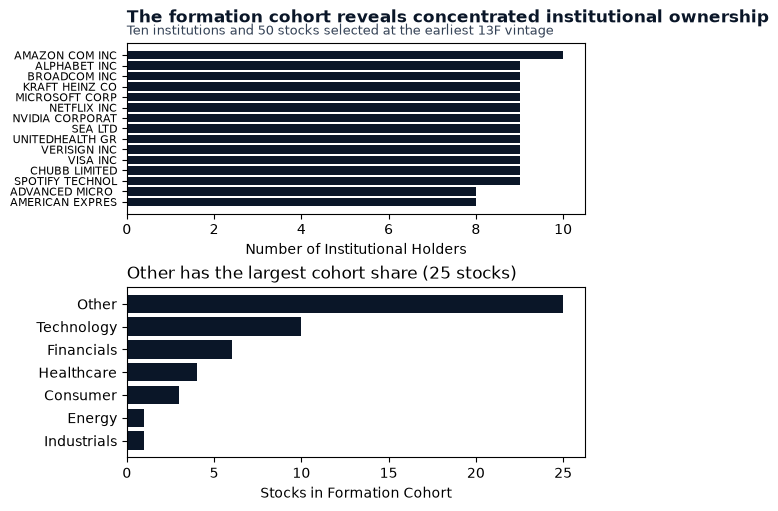

In [26]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], constrained_layout=True)

# Panel (a): Most crowded stocks (by holder count)
stock_holders = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS":
        stock_holders[edge.target_id] = stock_holders.get(edge.target_id, 0) + 1

if stock_holders:
    sorted_stocks = sorted(stock_holders.items(), key=lambda x: (-x[1], x[0]))[:15]
    names = []
    for cusip, _ in sorted_stocks:
        match = [s for s in data_stocks if s["cusip"] == cusip]
        names.append(match[0]["ticker"][:15] if match else cusip[:10])
    counts = [c for _, c in sorted_stocks]
    axes[0].barh(range(len(names)), counts, color=COLORS["blue"])
    axes[0].set_yticks(range(len(names)))
    axes[0].set_yticklabels(names, fontsize=8)
    axes[0].set_xlabel("Number of Institutional Holders")
    axes[0].invert_yaxis()

# Panel (b): Sector distribution
sector_counts = {}
for s in data_stocks:
    sector_counts[s["sector"]] = sector_counts.get(s["sector"], 0) + 1
if sector_counts:
    sector_rows = sorted(sector_counts.items(), key=lambda item: (-item[1], item[0]))
    sectors = [row[0] for row in sector_rows]
    scounts = [row[1] for row in sector_rows]
    axes[1].barh(sectors[::-1], scounts[::-1], color=COLORS["blue"])
    axes[1].set_xlabel("Stocks in Formation Cohort")
    axes[1].set_title(
        f"{sectors[0]} has the largest cohort share ({scounts[0]} stocks)", loc="left"
    )

add_message_title(
    axes[0],
    "The formation cohort reveals concentrated institutional ownership",
    subtitle="Ten institutions and 50 stocks selected at the earliest 13F vintage",
)
fig.show()

The left panel reports holder counts within the fixed ten-institution cohort.
These counts describe overlap; they do not measure the price impact of an unwind.

## 6. Top Holdings by Sector

Query combining holdings with sector information (or overall if no sectors).

In [27]:
# Get unique sectors
unique_sectors = set(s.get("sector", "Unknown") for s in data_stocks)
sector_to_analyze = "Technology" if "Technology" in unique_sectors else sorted(unique_sectors)[0]

print(f"QUERY 4: Top Holdings in {sector_to_analyze} Sector")
print()
print("Cypher equivalent:")
print(f"""
MATCH (i:Institution)-[h:HOLDS]->(s:Stock)-[:IN_SECTOR]->(sec:Sector {{name: '{sector_to_analyze}'}})
WITH s, SUM(h.value) AS total_ownership
RETURN s.ticker, s.issuer, total_ownership
ORDER BY total_ownership DESC
LIMIT 10
""")

QUERY 4: Top Holdings in Technology Sector

Cypher equivalent:

MATCH (i:Institution)-[h:HOLDS]->(s:Stock)-[:IN_SECTOR]->(sec:Sector {name: 'Technology'})
WITH s, SUM(h.value) AS total_ownership
RETURN s.ticker, s.issuer, total_ownership
ORDER BY total_ownership DESC
LIMIT 10



In [28]:
# Find stocks in sector and sum institutional ownership
sector_cusips = {s["cusip"] for s in data_stocks if s.get("sector") == sector_to_analyze}
print(f"\nStocks in {sector_to_analyze}: {len(sector_cusips)}")

sector_ownership: dict[str, int] = {}
for edge in graph.edges:
    if edge.edge_type == "HOLDS" and edge.target_id in sector_cusips:
        if edge.target_id not in sector_ownership:
            sector_ownership[edge.target_id] = 0
        sector_ownership[edge.target_id] += edge.properties["value"]


Stocks in Technology: 10


In [29]:
# Format and display results
print(f"Top Holdings in {sector_to_analyze}:")
sector_data = []
for cusip, value in sector_ownership.items():
    stock = graph.get_node(cusip)
    if stock:
        sector_data.append(
            {
                "ticker": stock.properties.get("ticker", ""),
                "issuer": stock.properties.get("issuer", cusip),
                "total_ownership_bn": value / 1_000_000_000,
            }
        )

sector_df = pl.DataFrame(sector_data).sort(
    ["total_ownership_bn", "ticker"], descending=[True, False]
)
sector_df.head(10)

Top Holdings in Technology:


ticker,issuer,total_ownership_bn
str,str,f64
"""APPLE INC""","""APPLE INC""",89.045473
"""NVIDIA CORPORAT""","""NVIDIA CORPORATION""",52.707688
"""ALPHABET INC""","""ALPHABET INC""",27.792508
"""MICROSOFT CORP""","""MICROSOFT CORP""",26.599257
"""AMAZON COM INC""","""AMAZON COM INC""",25.962678
"""META PLATFORMS ""","""META PLATFORMS INC""",24.70266
"""BROADCOM INC""","""BROADCOM INC""",17.781914
"""ALPHABET INC""","""ALPHABET INC""",12.590426
"""TAIWAN SEMICOND""","""TAIWAN SEMICONDUCTOR MFG LTD""",9.383838


## 7. Neo4j Loading

Load to Neo4j.

### Neo4j Loading Function

Load institutions, stocks, and holdings into Neo4j with idempotent `MERGE`
statements.

In [30]:
INSTITUTION_QUERY = """
UNWIND $rows AS row
MERGE (i:Institution {cik: row.cik})
SET i.name = row.name, i.aum = row.aum, i.strategy = row.strategy
"""

STOCK_QUERY = """
UNWIND $rows AS row
MERGE (s:Stock {cusip: row.cusip})
SET s.ticker = row.ticker, s.issuer = row.issuer, s.sector = row.sector
MERGE (sector:Sector {name: row.sector})
MERGE (s)-[:IN_SECTOR]->(sector)
"""

HOLDING_QUERY = """
UNWIND $rows AS row
MATCH (i:Institution {cik: row.cik})
MATCH (s:Stock {cusip: row.cusip})
MERGE (i)-[h:HOLDS {quarter: row.quarter}]->(s)
SET h.shares = row.shares, h.value = row.value
"""

### Neo4j Loading Function

Load institutions, stocks, and holdings into Neo4j with idempotent `MERGE`
statements.

### Neo4j Constraints

Create uniqueness constraints before loading records so repeated runs remain
idempotent and the graph enforces one node per institution or stock key.

In [31]:
def ensure_neo4j_constraints(session) -> None:
    """Create the constraints required by the holdings graph."""
    constraints = [
        "CREATE CONSTRAINT IF NOT EXISTS FOR (i:Institution) REQUIRE i.cik IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (s:Stock) REQUIRE s.cusip IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (s:Sector) REQUIRE s.name IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (s:GraphSnapshot) REQUIRE s.name IS UNIQUE",
    ]
    for constraint in constraints:
        session.run(constraint).consume()

### Holdings-Subgraph Reset

Replace only the labels owned by this producer so unrelated chapter graphs remain intact.

In [32]:
def clear_holdings_subgraph(session) -> None:
    """Clear only node labels owned by the 13F producer."""
    session.run("MATCH (n) WHERE n:Institution OR n:Stock OR n:Sector DETACH DELETE n").consume()

In [33]:
def build_graph_snapshot(holding_rows: list[dict[str, Any]]) -> dict[str, Any]:
    """Record the source bytes, cohort policy, vintages, and expected graph counts."""
    quarters = sorted({row["quarter"] for row in holding_rows})
    return {
        "name": "ch23_13f",
        "source_sha256": SOURCE_SHA256,
        "source_rows": SOURCE_ROWS,
        "formation_quarter": quarters[0],
        "latest_quarter": quarters[-1],
        "vintage_count": len(quarters),
        "institution_count": len(data_institutions),
        "stock_count": len(data_stocks),
        "holding_count": len(holding_rows),
        "cohort_policy": "earliest-vintage formation, fixed forward",
        "vintage_basis": "filing-date availability clusters, not SEC reportDate",
    }

In [34]:
def read_graph_counts(session) -> dict[str, int]:
    """Read the exact holdings-subgraph counts after loading."""
    return (
        session.run(
            """
        MATCH (i:Institution) WITH count(i) AS institutions
        MATCH (s:Stock) WITH institutions, count(s) AS stocks
        MATCH (:Institution)-[h:HOLDS]->(:Stock)
        WITH institutions, stocks, count(h) AS holdings
        MATCH (:Stock)-[r:IN_SECTOR]->(:Sector)
        RETURN institutions, stocks, holdings, count(r) AS sector_edges
        """
        )
        .single()
        .data()
    )

### Neo4j Loading Function

Load institutions, stocks, and holdings into Neo4j with idempotent `MERGE`
statements.

In [35]:
def load_13f_to_neo4j() -> dict:
    """Load 13F data to Neo4j database.

    Returns stats dict with counts of loaded entities/relationships.
    """
    holding_rows = [
        {"cik": cik, "cusip": cusip, "shares": shares, "value": value, "quarter": quarter}
        for cik, cusip, shares, value, quarter in data_holdings_all_vintages
    ]
    snapshot = build_graph_snapshot(holding_rows)
    print("Loading to Neo4j...")
    with NEO4J_DRIVER.session() as session:
        ensure_neo4j_constraints(session)
        clear_holdings_subgraph(session)
        session.run(INSTITUTION_QUERY, rows=data_institutions).consume()
        session.run(STOCK_QUERY, rows=data_stocks).consume()
        session.run(HOLDING_QUERY, rows=holding_rows).consume()
        session.run(
            "MERGE (s:GraphSnapshot {name: $snapshot.name}) SET s = $snapshot",
            snapshot=snapshot,
        ).consume()
        stats = read_graph_counts(session)
    expected = {
        "institutions": len(data_institutions),
        "stocks": len(data_stocks),
        "holdings": len(holding_rows),
        "sector_edges": len(data_stocks),
    }
    assert stats == expected, f"Neo4j load mismatch: {stats=} {expected=}"
    print(f"Loaded and verified: {stats}")
    print(f"Graph snapshot: {snapshot}")
    return {**stats, **snapshot}

In [36]:
# Load to Neo4j
neo4j_stats = load_13f_to_neo4j()

Loading to Neo4j...
Loaded and verified: {'institutions': 10, 'stocks': 50, 'holdings': 1490, 'sector_edges': 50}
Graph snapshot: {'name': 'ch23_13f', 'source_sha256': '6f27cbe8d2574861b8a97ddd6958a93234b062f3b10b0b9ebe46723c772e6c1d', 'source_rows': 201145, 'formation_quarter': '2025-05-15', 'latest_quarter': '2026-02-17', 'vintage_count': 4, 'institution_count': 10, 'stock_count': 50, 'holding_count': 1490, 'cohort_policy': 'earliest-vintage formation, fixed forward', 'vintage_basis': 'filing-date availability clusters, not SEC reportDate'}


## 8. Summary Statistics

Key statistics for Chapter 23 integration.

In [37]:
# Compute statistics
n_institutions = len(data_institutions)
n_stocks = len(data_stocks)
n_holdings = len(data_holdings)
n_sectors = len(sectors)

avg_holdings_per_inst = n_holdings / n_institutions if n_institutions > 0 else 0
avg_holders_per_stock = n_holdings / n_stocks if n_stocks > 0 else 0

max_crowding = max(len(h) for h in stock_holder_sets.values()) if stock_holder_sets else 0
most_crowded = []
for c, h in stock_holder_sets.items():
    if len(h) == max_crowding:
        node = graph.get_node(c)
        if node:
            name = node.properties.get("ticker") or node.properties.get("issuer", c)
            most_crowded.append(name)

max_sim = sim_df.row(0) if len(sim_df) > 0 else None

n_vintage_holdings = len(data_holdings_all_vintages)
n_vintages = len({h[4] for h in data_holdings_all_vintages})

In [38]:
summary_rows = [
    ("Data source", data_source),
    ("Institutions", n_institutions),
    ("Stocks", n_stocks),
    ("Sectors", n_sectors),
    ("Holdings relationships (latest)", n_holdings),
    (
        "Vintage HOLDS edges (Neo4j)",
        f"{n_vintage_holdings} across {n_vintages} filing vintages",
    ),
    ("Avg holdings per inst", f"{avg_holdings_per_inst:.1f}"),
    ("Avg holders per stock", f"{avg_holders_per_stock:.1f}"),
    ("Max crowding (holders)", max_crowding),
    ("Shared holdings pairs", len(sim_df)),
    ("Neo4j loaded", "Yes" if NEO4J_DRIVER else "No"),
]
if most_crowded:
    most_crowded.sort()
    summary_rows.insert(8, ("Most crowded stocks", ", ".join(most_crowded[:5])))
if max_sim:
    summary_rows.insert(
        -1, ("Highest similarity pair", f"{max_sim[0]}-{max_sim[1]} ({max_sim[2]:.3f})")
    )
summary_df = pl.DataFrame(
    {"Metric": [r[0] for r in summary_rows], "Value": [str(r[1]) for r in summary_rows]}
)
summary_df

Metric,Value
str,str
"""Data source""","""EDGAR 13F"""
"""Institutions""","""10"""
"""Stocks""","""50"""
"""Sectors""","""7"""
"""Holdings relationships (latest…","""377"""
…,…
"""Most crowded stocks""","""AMAZON COM INC"""
"""Max crowding (holders)""","""10"""
"""Shared holdings pairs""","""1225"""


The summary table fixes the scope and reports each count from the executed
graph. The most crowded stocks are held by a majority of the sampled
institutions, and the highest Jaccard pair shares most of its holders. The same
information can be derived from the flat 13F table via groupby; the graph
representation makes multi-hop traversals (e.g. "stocks connected to
Berkshire's holdings through any other holder") expressible in a single
query.

## 9. Verification

In [39]:
print(f"Data source: {data_source}")
print(f"Neo4j: {'Connected' if NEO4J_DRIVER else 'Not connected'}")
print(f"Graph: {len(graph.nodes)} nodes, {len(graph.edges)} edges")
print("Queries demonstrated: 4")
print(f"Co-ownership pairs computed: {len(similarities)}")
print()
if most_crowded:
    crowded_str = ", ".join(most_crowded[:3])
    print(f"Highest observed holder count: {crowded_str} ({max_crowding} holders)")
    print("This is descriptive ownership overlap; return effects are not evaluated.")

completion_record = {
    "source_sha256": SOURCE_SHA256,
    "source_rows": SOURCE_ROWS,
    "formation_vintage": neo4j_stats["formation_quarter"],
    "latest_vintage": neo4j_stats["latest_quarter"],
    "vintage_count": n_vintages,
    "institutions": n_institutions,
    "stocks": n_stocks,
    "holdings_latest": n_holdings,
    "holdings_all_vintages": n_vintage_holdings,
    "sector_edges": neo4j_stats["sector_edges"],
    "graph_nodes": len(graph.nodes),
    "graph_edges": len(graph.edges),
    "shared_holding_pairs": len(similarities),
    "max_holder_count": max_crowding,
    "highest_jaccard": float(max_sim[2]) if max_sim else None,
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True))
NEO4J_DRIVER.close()

Data source: EDGAR 13F
Neo4j: Connected
Graph: 67 nodes, 427 edges
Queries demonstrated: 4
Co-ownership pairs computed: 1225

Highest observed holder count: AMAZON COM INC (10 holders)
This is descriptive ownership overlap; return effects are not evaluated.
COMPLETION_RECORD={"formation_vintage": "2025-05-15", "graph_edges": 427, "graph_nodes": 67, "highest_jaccard": 1.0, "holdings_all_vintages": 1490, "holdings_latest": 377, "institutions": 10, "latest_vintage": "2026-02-17", "max_holder_count": 10, "sector_edges": 50, "shared_holding_pairs": 1225, "source_rows": 201145, "source_sha256": "6f27cbe8d2574861b8a97ddd6958a93234b062f3b10b0b9ebe46723c772e6c1d", "stocks": 50, "vintage_count": 4}


## Key Takeaways

1. **13F filings form a bipartite graph** -- institutions connected to stocks
   through HOLDS edges with value, share count, and a filing-availability
   vintage stored under the legacy `quarter` key.
2. **Graph queries express ownership patterns directly**: shared holdings,
   network paths, and multi-hop sector aggregations are single Cypher
   traversals; the equivalent SQL requires self-joins on the holdings table.
   This notebook does not benchmark Cypher vs SQL execution time.
3. **Jaccard co-ownership similarity** projects the bipartite graph into a
   stock-stock network. Within the fixed formation cohort, the highest-similarity
   pair shares most of its institutional holders. The notebook does not
   measure how this co-ownership structure relates to return correlation.
4. **Crowding detection** identifies stocks held by many of the sampled
   institutions simultaneously. Whether this concentration translates to
   amplified drawdowns during unwinds is not measured here.
5. **Neo4j persistence** supports live point-in-time queries over the loaded
   filing-availability vintages; the in-memory graph supports the
   single-vintage teaching queries.

**Next**: See `07_dynamic_kg_temporal` for how this ownership graph evolves over
time, enabling trend detection in institutional positioning.

**Book**: Section 23.4 discusses ownership-graph features (crowding, smart-
money concentration, ownership HHI, co-ownership Jaccard); Section 23.7
covers the production engineering decisions for KG schema and incremental
quarterly updates from EDGAR.